In [31]:
import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt

In [32]:
data_results = pl.read_csv('bench_results.csv')

In [33]:
median_data = data_results.group_by('case', maintain_order=True).median()

In [34]:
median_data.head()

case,clock,ms
str,f64,f64
"""double_intrin_avx2""",4.05876097e8,150.995189
"""float_intrin_avx2""",2.07896588e8,77.342195
"""double_intrin_avx512""",2.13680792e8,79.494451
"""float_intrin_avx512""",1.05686145e8,39.31883
"""double_simple""",1.3175e9,490.157887


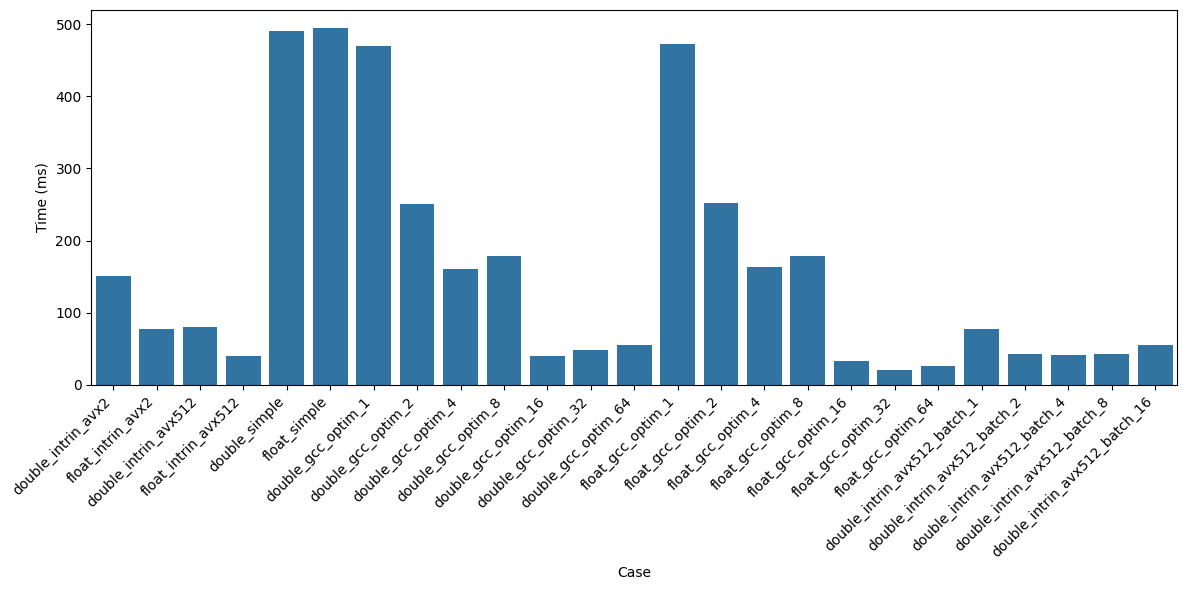

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(data=median_data, x='case', y='ms')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()

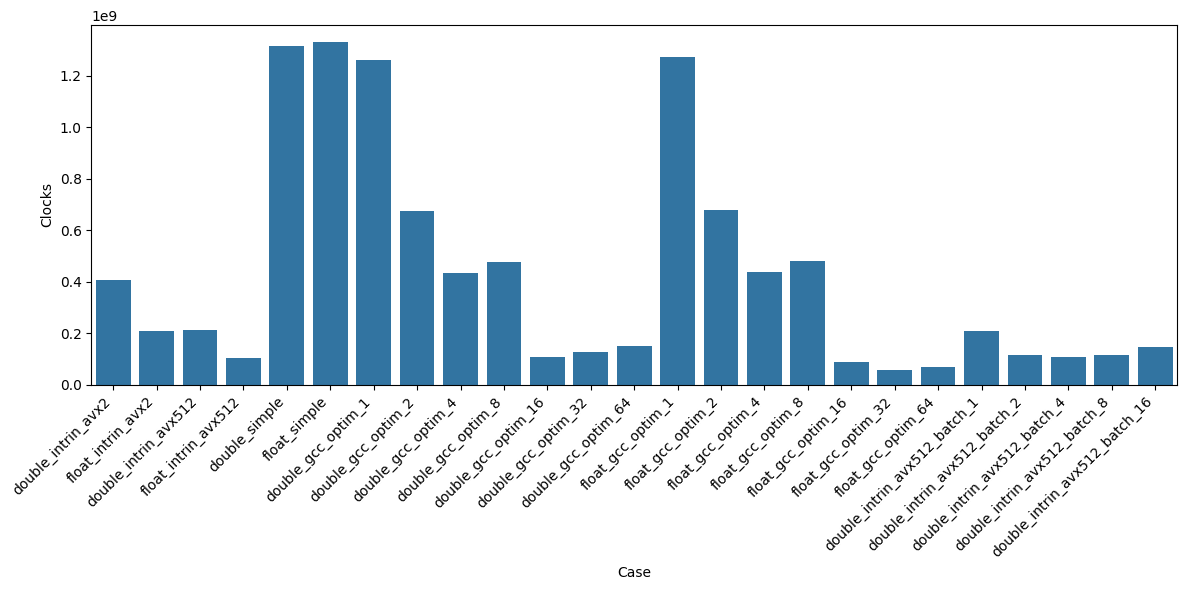

In [36]:
plt.figure(figsize=(12, 6))
sns.barplot(data=median_data, x='case', y='clock')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Clocks')

plt.tight_layout()
plt.show()

In [37]:
lookup_cases = ['double_intrin_avx512_batch_1',
                'double_intrin_avx512',
                'float_intrin_avx512',
                'double_gcc_optim_16',
               'double_intrin_avx512_batch_2',
               'double_intrin_avx512_batch_4',
               'double_intrin_avx512_batch_8',
               'double_intrin_avx512_batch_16']

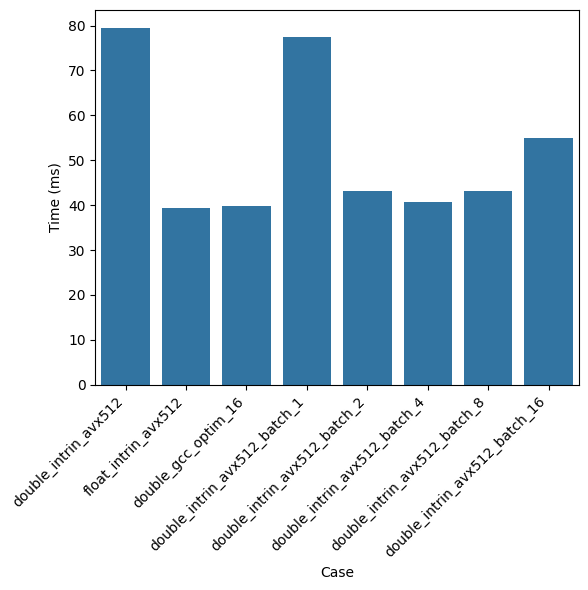

In [38]:
plt.figure(figsize=(6, 6))
sns.barplot(data=median_data.filter(pl.col('case').is_in(lookup_cases)), x='case', y='ms')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()

In [39]:
boxplot_lookup_cases = [
                'float_intrin_avx512',
                'double_gcc_optim_16',
               'double_intrin_avx512_batch_2',
               'double_intrin_avx512_batch_4',
               'double_intrin_avx512_batch_8']

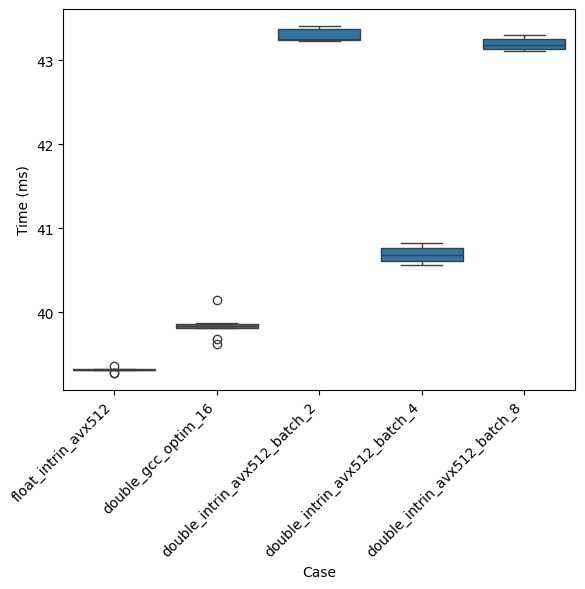

In [40]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=data_results.filter(pl.col('case').is_in(boxplot_lookup_cases)), x='case', y='ms')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()

## OMP

In [41]:
data_results = pl.read_csv('OMP_results.csv')

In [42]:
median_data = data_results.group_by('case', maintain_order=True).median()
median_data.head()

case,clock,ms
str,f64,f64
"""OMP_double_intrin_avx2""",2.96821077e8,110.425031
"""OMP_double_intrin_avx512""",1.65016766e8,61.390684
"""OMP_double_intrin_avx512_batch…",1.64696372e8,61.271405
"""OMP_double_intrin_avx512_batch…",1.46663174e8,54.562734
"""OMP_double_intrin_avx512_batch…",1.47883223e8,55.016323


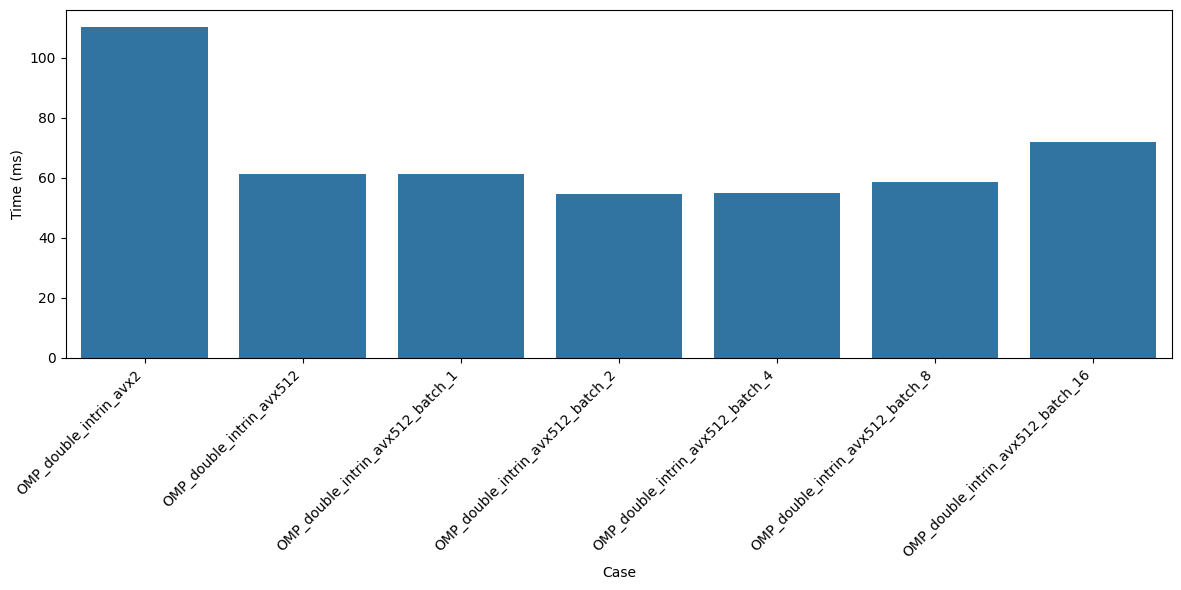

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(data=median_data, x='case', y='ms')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()

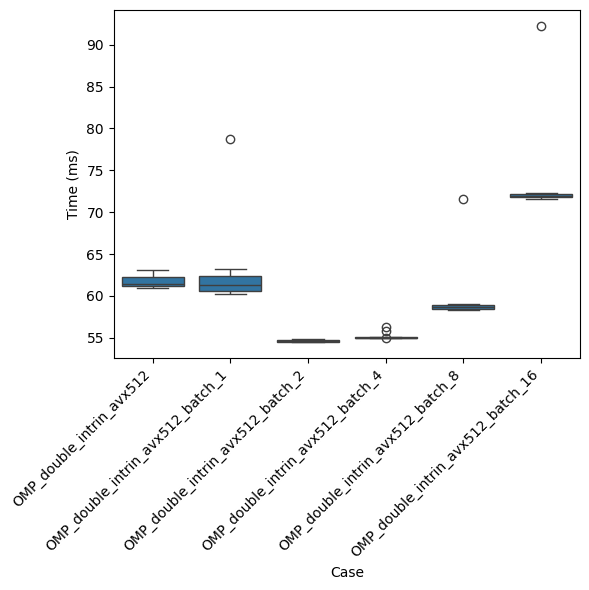

In [46]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=data_results.filter(pl.col('case').is_in(['OMP_double_intrin_avx2']).not_()), x='case', y='ms')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()